In [64]:
import numpy as np

# siatka spinów 2D, gdzie każdy spin może przyjmować wartość +1 lub -1
def init_lattice(N):
    return np.random.choice([-1, 1], size=(N, N))

def delta_E(spins, i, j, J, B):
    N = spins.shape[0]

    
    s = spins[i, j]

    # nn=0 
    # for a in range(i-1,i+1):
    #     for b in range(j-1,j+1):
    #         if a==i and b==j:
    #             continue
    #         nn+=spins[a%N,b%N]


    nn = (#sumuje sąsiadów 4 na górze i dole oraz 4 na przekątnych
        spins[(i+1)%N, j] + spins[(i-1)%N, j] +#%N oznaczaza warunkowe indeksowanie, które pozwala na "owijanie" siatki
        spins[i, (j+1)%N] + spins[i, (j-1)%N] +
        spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
        spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
    )

    return 2 * s * (J * nn + B)

def magnetization(spins):
    return np.mean(spins)

def energy(spins, J, B):# z hamiltonian Isinga
    N = spins.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            nn = (# sumuje sąsiadów 
               #H = -J \sum_{\langle i,j \rangle} s_i s_j - B \sum_i s_i,
                spins[(i+1)%N, j] + spins[(i-1)%N, j] +
                spins[i, (j+1)%N] + spins[i, (j-1)%N] +
                spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
                spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
            )
            E += (-J * s * nn)/2 - B * s
    return E

def simulate(spins,N, M, J, B, beta,):

    mags = []
    energies = []
    frames = []

    for step in range(M):
        for _ in range(N * N):
            i = np.random.randint(0, N)# losowa licba z zakresu 0 do N
            j = np.random.randint(0, N)

            dE = delta_E(spins, i, j, J, B)
            if dE < 0 or np.random.rand() < np.exp(-beta * dE):
                spins[i, j] *= -1

        mags.append(magnetization(spins))
        energies.append(energy(spins, J, B))
        frames.append(spins.copy())

    return spins, np.array(mags), np.array(energies), frames


In [65]:
from numba import njit
import numpy as np

@njit
def delta_E_numba(spins, i, j, J, B):
    N = spins.shape[0]
    s = spins[i, j]

    nn = (
        spins[(i+1)%N, j] + spins[(i-1)%N, j] +
        spins[i, (j+1)%N] + spins[i, (j-1)%N] +
        spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
        spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
    )

    return 2 * s * (J * nn + B)



@njit
def energy_numba(spins, J, B):
    N = spins.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            nn = (
                 spins[(i+1)%N, j] + spins[(i-1)%N, j] +
                 spins[i, (j+1)%N] + spins[i, (j-1)%N] +
                 spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
                 spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
                )
            E += (-J * s * nn)/2 - B * s
    return E

@njit
def magnetization_numba(spins):
    return np.mean(spins)

@njit
def simulate_numba(spins, M, J, B, beta):
    N = spins.shape[0]

    mags = np.zeros(M)
    energies = np.zeros(M)
    frames = np.zeros((M, N, N))

    for step in range(M):
        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            dE = delta_E_numba(spins, i, j, J, B)

            if dE < 0 or np.random.rand() < np.exp(-beta * dE):
                spins[i, j] *= -1

        mags[step] = magnetization_numba(spins)
        energies[step] = energy_numba(spins, J, B)
        frames[step] = spins.copy()

    return spins, mags, energies, frames

In [66]:
import time

N = 50
M = 100
J = 1.0
B = 0.5
beta = 0.4

np.random.seed(1234)
initial_spins = init_lattice(N)

start = time.time()
spins_py, mags_py, energies_py, frames_py = simulate(
    initial_spins.copy(),
    N=N,
    M=M,
    J=J,
    B=B,
    beta=beta,
)
python_time = time.time() - start

compile_start = time.time()
simulate_numba(initial_spins.copy(), M, J, B, beta)
compile_time = time.time() - compile_start


start = time.time()
spins_nb, mags_nb, energies_nb, frames_nb = simulate_numba(initial_spins.copy(), M, J, B, beta)
numba_time = time.time() - start

print(f"Czas wykonania (Python): {python_time:.4f} s")
print(f"koszt kompilacji (Numba): {compile_time:.4f} s")
print(f"Czas wykonania (Numba): {numba_time:.4f} s")


Czas wykonania (Python): 3.5710 s
koszt kompilacji (Numba): 1.6027 s
Czas wykonania (Numba): 0.0227 s


In [61]:
spins_nb, spins_py


(array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], shape=(50, 50)),
 array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], shape=(50, 50)))

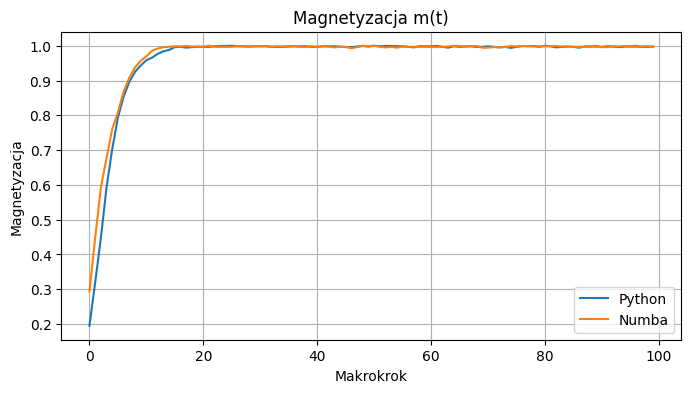

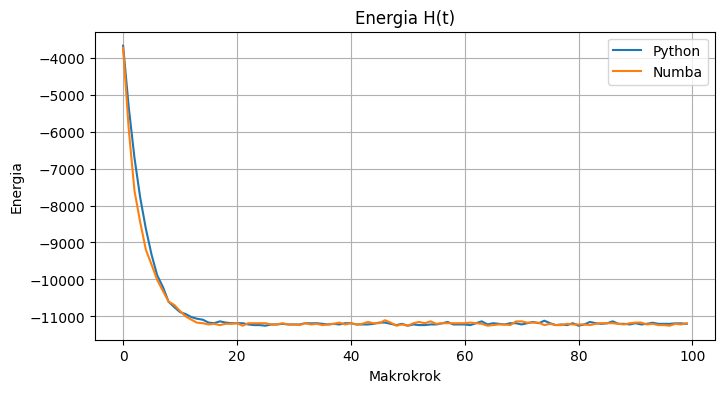

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(mags_py, label='Python')
plt.plot(mags_nb, label='Numba')
plt.xlabel('Makrokrok')
plt.ylabel('Magnetyzacja')
plt.title('Magnetyzacja m(t)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(energies_py, label='Python')
plt.plot(energies_nb, label='Numba')
plt.xlabel('Makrokrok')
plt.ylabel('Energia')
plt.title('Energia H(t)')
plt.grid(True)
plt.legend()
plt.show()

In [68]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames_py[0], cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Ewolucja układu spinów')
ax.axis('off')

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames_py, interval=200, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())